<a href="https://colab.research.google.com/github/renegarcialuces/Analisis-de-Datos-Portafolio/blob/main/ED04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
filename = '/content/drive/MyDrive/Tablas/HistorialMasacresUSA.csv'
df = pd.read_csv(filename, usecols=[0, 1, 2, 3, 4, 5])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2488 entries, 0 to 2487
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     2488 non-null   object
 1   City     2488 non-null   object
 2   State    2488 non-null   object
 3   Dead     2488 non-null   int64 
 4   Injured  2488 non-null   int64 
 5   Total    2488 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 116.8+ KB


# **Preparacion de datos**

In [25]:
# Cambiando tipo de columna de object a datatime
df['Date'] = pd.to_datetime(df['Date'])
# Transformat tipo calumna object a category
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = df[col].astype('category')

# **Creacion de datos temporales**

In [28]:
df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%b')
df['Weekday'] = df['Date'].dt.day_name()
df['Letality_Rate'] = (df['Dead'] / df['Total'].replace(0, np.nan)).fillna(0).round(3)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2488 entries, 0 to 2487
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           2488 non-null   datetime64[ns]
 1   City           2488 non-null   category      
 2   State          2488 non-null   category      
 3   Dead           2488 non-null   int64         
 4   Injured        2488 non-null   int64         
 5   Total          2488 non-null   int64         
 6   Year           2488 non-null   int32         
 7   Month          2488 non-null   int32         
 8   MonthName      2488 non-null   object        
 9   Weekday        2488 non-null   object        
 10  Letality_Rate  2488 non-null   float64       
dtypes: category(2), datetime64[ns](1), float64(1), int32(2), int64(3), object(2)
memory usage: 204.0+ KB


# **KPIs**

In [37]:
total_incidentes    = len(df)
total_muertos       = df['Dead'].sum()
total_heridos       = df['Injured'].sum()
total_victimas      = df['Total'].sum()
promedio_muertos    = df['Dead'].mean().round(2)
promedio_heridos    = df['Injured'].mean().round(2)
tasa_letalidad_gbl  = (total_muertos / total_victimas * 100).round(2)
incidente_mas_letal = df.loc[df['Dead'].idxmax()]
estado_top          = df['State'].value_counts().idxmax()

print("\n=== KPIs GLOBALES ===")
print(f"  Total incidentes      : {total_incidentes:,}")
print(f"  Total muertos         : {total_muertos:,}")
print(f"  Total heridos         : {total_heridos:,}")
print(f"  Total víctimas        : {total_victimas:,}")
print(f"  Promedio muertos/inc. : {promedio_muertos}")
print(f"  Promedio heridos/inc. : {promedio_heridos}")
print(f"  Tasa de letalidad (%) : {tasa_letalidad_gbl}%")
print(f"  Estado con más casos  : {estado_top}")
print(f"  Incidente más letal   : {incidente_mas_letal['Date'].date()} — {incidente_mas_letal['City']}, {incidente_mas_letal['State']} — {incidente_mas_letal['Dead']} muertos")


=== KPIs GLOBALES ===
  Total incidentes      : 2,488
  Total muertos         : 2,580
  Total heridos         : 10,145
  Total víctimas        : 12,722
  Promedio muertos/inc. : 1.04
  Promedio heridos/inc. : 4.08
  Tasa de letalidad (%) : 20.28%
  Estado con más casos  : Illinois
  Incidente más letal   : 2019-08-03 — El Paso, Texas — 23 muertos


# **PREGUNTAS DE NEGOCIO** ──────────────────────────────────────────

##### P1. ¿Cuál es la tendencia anual del número de incidentes y víctimas totales?
##### P2. ¿Qué estados concentran la mayor cantidad de incidentes y víctimas?
##### P3. ¿Existe un patrón estacional (mes / día de semana)?
##### P4. ¿Cómo se distribuye la relación entre muertos e heridos por incidente?
##### P5. ¿Cuáles son los incidentes más letales del período?

In [35]:
# Seleccionando la PALETTE
plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = ['#C0392B','#E74C3C','#F39C12','#2980B9','#1ABC9C','#8E44AD']

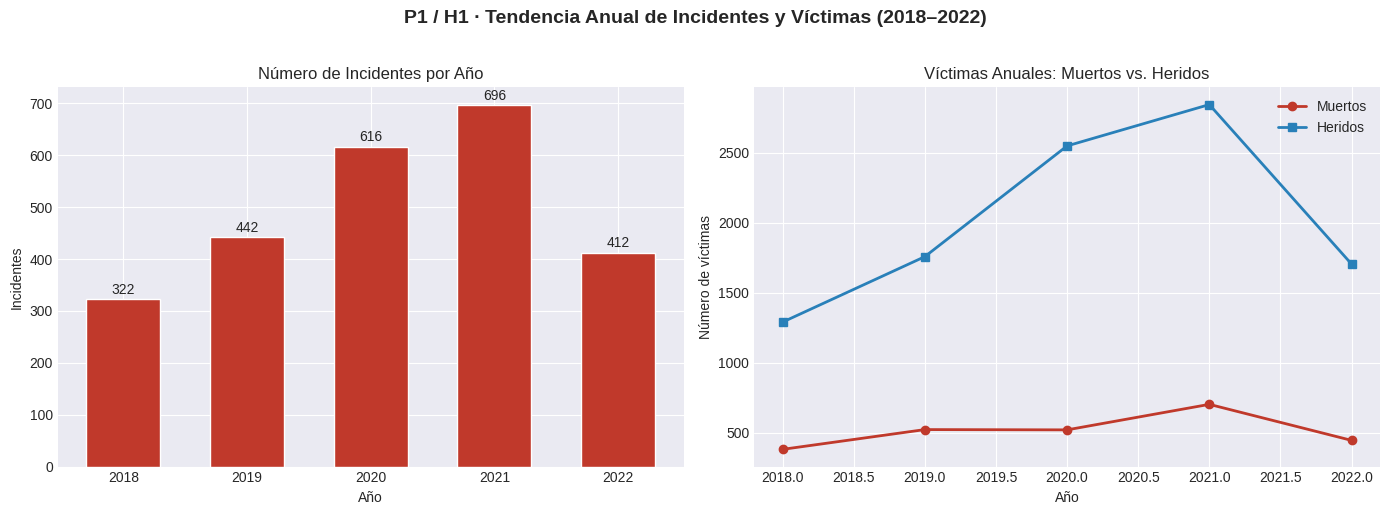

✔ viz1_tendencia_anual.png guardado


In [36]:
# Tendencia anual — Incidentes y víctimas
anual = df.groupby('Year').agg(
    Incidentes=('Date','count'),
    Muertos=('Dead','sum'),
    Heridos=('Injured','sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('P1 / H1 · Tendencia Anual de Incidentes y Víctimas (2018–2022)',
             fontsize=14, fontweight='bold', y=1.02)

ax1 = axes[0]
bars = ax1.bar(anual['Year'], anual['Incidentes'], color=PALETTE[0], edgecolor='white', width=0.6)
ax1.set_title('Número de Incidentes por Año')
ax1.set_xlabel('Año'); ax1.set_ylabel('Incidentes')
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f"{int(bar.get_height())}", ha='center', va='bottom', fontsize=10)

ax2 = axes[1]
ax2.plot(anual['Year'], anual['Muertos'], marker='o', color=PALETTE[0], label='Muertos', linewidth=2)
ax2.plot(anual['Year'], anual['Heridos'], marker='s', color=PALETTE[3], label='Heridos', linewidth=2)
ax2.set_title('Víctimas Anuales: Muertos vs. Heridos')
ax2.set_xlabel('Año'); ax2.set_ylabel('Número de víctimas')
ax2.legend()

plt.tight_layout()
plt.savefig('viz1_tendencia_anual.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("✔ viz1_tendencia_anual.png guardado")

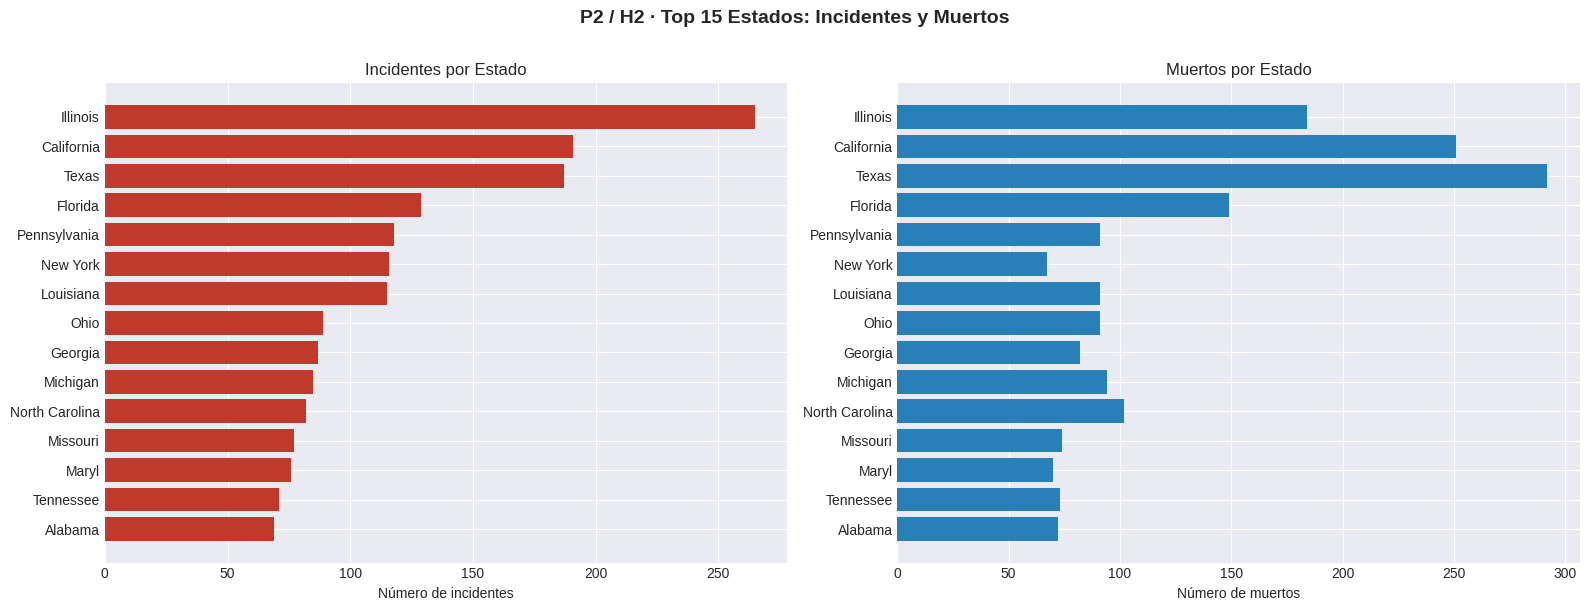

✔ viz2_top_estados.png guardado

  H2 · Los 4 estados top representan el 31.0% de los incidentes


In [44]:
# 15 estados por incidentes y víctimas
estados = df.groupby('State', observed=False).agg(
    Incidentes=('Date','count'),
    Muertos=('Dead','sum'),
    Heridos=('Injured','sum')
).sort_values('Incidentes', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('P2 / H2 · Top 15 Estados: Incidentes y Muertos', fontsize=14,
             fontweight='bold', y=1.01)

axes[0].barh(estados.index[::-1], estados['Incidentes'][::-1], color=PALETTE[0])
axes[0].set_title('Incidentes por Estado')
axes[0].set_xlabel('Número de incidentes')

axes[1].barh(estados.index[::-1], estados['Muertos'][::-1], color=PALETTE[3])
axes[1].set_title('Muertos por Estado')
axes[1].set_xlabel('Número de muertos')

plt.tight_layout()
plt.savefig('viz2_top_estados.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("✔ viz2_top_estados.png guardado")

# Verificación H2: % de los 4 estados top
top4 = ['Illinois','California','Texas','Florida']
pct_top4 = df[df['State'].isin(top4)].shape[0] / total_incidentes * 100
print(f"\n  H2 · Los 4 estados top representan el {pct_top4:.1f}% de los incidentes")

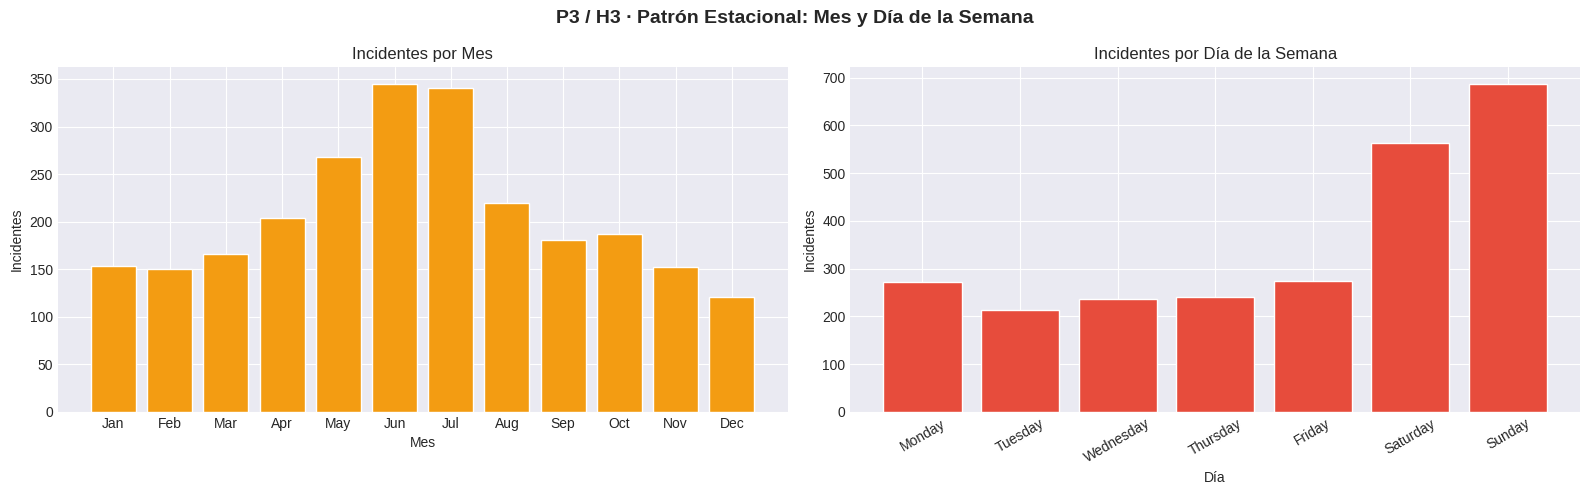

✔ viz3_patron_estacional.png guardado


In [39]:
# Patrón estacional — mes y día de semana
mes_orden = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
dia_orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

mensual = df.groupby('MonthName').size().reindex(mes_orden)
semanal = df.groupby('Weekday').size().reindex(dia_orden)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('P3 / H3 · Patrón Estacional: Mes y Día de la Semana', fontsize=14,
             fontweight='bold')

axes[0].bar(mensual.index, mensual.values, color=PALETTE[2], edgecolor='white')
axes[0].set_title('Incidentes por Mes')
axes[0].set_xlabel('Mes'); axes[0].set_ylabel('Incidentes')

axes[1].bar(semanal.index, semanal.values, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Incidentes por Día de la Semana')
axes[1].set_xlabel('Día'); axes[1].set_ylabel('Incidentes')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('viz3_patron_estacional.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("✔ viz3_patron_estacional.png guardado")

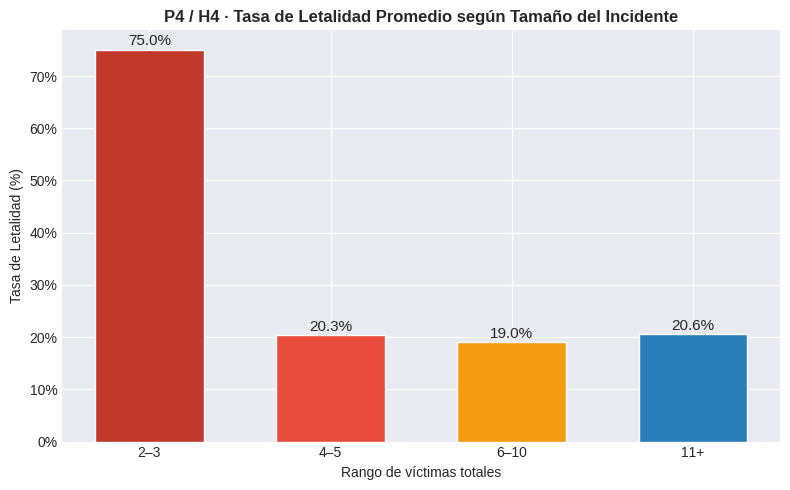

✔ viz4_tasa_letalidad_escala.png guardado


In [40]:
# Tasa de letalidad según escala del incidente
df['Escala'] = pd.cut(df['Total'], bins=[1,3,5,10,50],
                      labels=['2–3','4–5','6–10','11+'])
letalidad_escala = df.groupby('Escala', observed=True)['Letality_Rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(letalidad_escala['Escala'].astype(str),
              letalidad_escala['Letality_Rate']*100,
              color=PALETTE[:4], edgecolor='white', width=0.6)
ax.set_title('P4 / H4 · Tasa de Letalidad Promedio según Tamaño del Incidente',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Rango de víctimas totales')
ax.set_ylabel('Tasa de Letalidad (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('viz4_tasa_letalidad_escala.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("✔ viz4_tasa_letalidad_escala.png guardado")

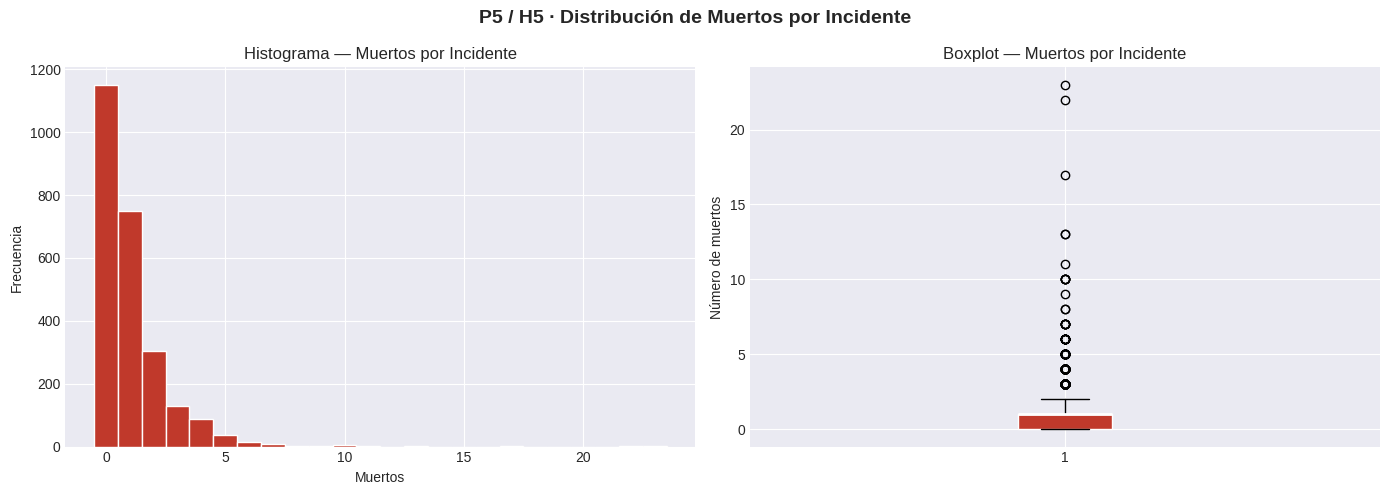

✔ viz5_distribucion_muertos.png guardado

  H5 · Incidentes con 0–2 muertos representan el 88.5%


In [41]:
# Distribución de muertos por incidente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('P5 / H5 · Distribución de Muertos por Incidente', fontsize=14,
             fontweight='bold')

axes[0].hist(df['Dead'], bins=range(0, df['Dead'].max()+2), color=PALETTE[0],
             edgecolor='white', align='left')
axes[0].set_title('Histograma — Muertos por Incidente')
axes[0].set_xlabel('Muertos'); axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['Dead'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], color='white'),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_title('Boxplot — Muertos por Incidente')
axes[1].set_ylabel('Número de muertos')

plt.tight_layout()
plt.savefig('viz5_distribucion_muertos.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("✔ viz5_distribucion_muertos.png guardado")

# Verificación H5
pct_0_2 = (df['Dead'] <= 2).sum() / total_incidentes * 100
print(f"\n  H5 · Incidentes con 0–2 muertos representan el {pct_0_2:.1f}%")